---
# <div style="text-align: center">Import into SCOPE</div>
---

This notebook imports cell2mol `Cell` objects (Part 1), XYZ files (Part 2), and RDKit molecules (Part 3) into SCOPE. The original data comes from:

- the published cell2mol dataset available in [Materials Cloud](https://archive.materialscloud.org/records/cdt4h-yvv48)
- the FORMED dataset available in [Materials Cloud](https://archive.materialscloud.org/records/20dc5-mvx03)
- the QM9 subset of the [GEOM dataset](https://github.com/learningmatter-mit/geom).

# Part 0: Configuration

The datasets are stored outside the repository. Set `datasets_folder` in the configuration cell below to their common parent folder. The expected structure is:

```text
<datasets_folder>/
├── cell2mol/
│   ├── 1-Iron/
│   │   ├── Cell_ABEMAX.gmol
│   │   ├── Cell_ABIJEB.gmol
│   │   └── ...
│   ├── 2-Manganese/
│   ├── 3-Ruthenium/
│   ├── 4-Rhenium/
│   ├── 5-Chromium/
│   ├── 6-Cobalt/
│   ├── 7-Nickel/
│   └── 8-Copper/
├── formed/
│   ├── AAXTHP.xyz
│   ├── ABABAI.xyz
│   └── ...
└── rdkit_folder/
    ├── summary_qm9.json
    └── qm9/
        ├── <molecule>.pickle
        └── ...
```

A benchmark part is skipped when its dataset folder is unavailable.

In [1]:
import csv
import os
import sys

import scope
from rdkit import rdBase

sys.path.insert(0, os.path.abspath('..'))
from benchmark_functions import compare_rdkit_scope_molecules, load_geom_rdkit_molecule, select_cell_paths, select_mol_paths, select_xyz_paths, validate_cell_molecule, validate_xyz_molecule

# Datasets are not uploaded to the repository. Download them from the links above and set their common parent folder here.
benchmark_folder        = os.path.abspath('./')
datasets_folder         = os.path.abspath('/Volumes/Science/Datasets')
cell2mol_dataset_folder = os.path.join(datasets_folder, 'cell2mol')
formed_dataset_folder   = os.path.join(datasets_folder, 'formed')
mols_dataset_folder     = os.path.join(datasets_folder, 'rdkit_folder')

# Selected input paths and benchmark results are kept with the notebook.
cell_selection_file     = os.path.join(benchmark_folder, 'selected_cell_paths.txt')
xyz_selection_file      = os.path.join(benchmark_folder, 'selected_xyz_paths.txt')
mol_selection_file      = os.path.join(benchmark_folder, 'selected_mol_paths.txt')
cell_results_file       = os.path.join(benchmark_folder, 'cell_import_results.csv')
xyz_results_file        = os.path.join(benchmark_folder, 'xyz_import_results.csv')
mol_results_file        = os.path.join(benchmark_folder, 'rdkit_import_results.csv')

## Set the number of entries to be evaluated.
ncells = 5000
nxyzs  = 5000
nmols  = 5000

## Create a new selection and repeat its comparison if True; otherwise, reuse existing selection and result files.
overwrite_cell_selection = False
overwrite_xyz_selection  = False
overwrite_mol_selection  = True

# Part 1: Import of cell2mol unit cells

The import follows the procedure illustrated in Part 2, Section 1c of Tutorial 1. Successful SCOPE Cells remain in memory; the original cell2mol files are not modified. The selected paths and comparison results are stored in `selected_cell_paths.txt` and `cell_import_results.csv`, respectively.

## 1. Select cell2mol Cell objects


In [2]:
## Reuse the existing Cell selection unless overwrite is requested.

cell2mol_dataset_available = os.path.isdir(cell2mol_dataset_folder)
relative_cell_paths        = []
cell_paths                 = []
cell_selection_created     = False

if not cell2mol_dataset_available:
    print(f'Skipping Part 1: Cell dataset not found at {cell2mol_dataset_folder}')
else:
    if os.path.isfile(cell_selection_file) and not overwrite_cell_selection:
        with open(cell_selection_file, 'r', encoding='utf-8') as selected_file:
            relative_cell_paths = [line.strip() for line in selected_file if line.strip()]
        print('Loaded existing Cell path selection')
    else:
        relative_cell_paths    = select_cell_paths(ncells, cell2mol_dataset_folder)
        cell_selection_created = True
        with open(cell_selection_file, 'w', encoding='utf-8') as selected_file:
            selected_file.write('\n'.join(relative_cell_paths))
        print('Created new Cell path selection')

    cell_paths = [os.path.join(cell2mol_dataset_folder, path) for path in relative_cell_paths]

    assert len(cell_paths) == ncells, f'Expected {ncells} paths; found {len(cell_paths)}'
    assert len(set(cell_paths)) == ncells, 'The selected path list contains repeated entries'
    assert all(os.path.isfile(path) for path in cell_paths), 'At least one selected Cell file is missing'
    print('Selected Cell files:', len(cell_paths))

Loaded existing Cell path selection
Selected Cell files: 5000


## 2. Import and Validate all selected Cells

Here, Cells are imported to SCOPE, and every molecule is validated based on:

- The number of Molecules in each Cell
- The number of Ligands and Metals in those Molecules
- The labels, coordinates, formula, and adjacency matrix of all Molecules
- The charge and coordination of Metals
- The formula and charge of Ligands

Every comparison produces one row in `cell_import_results.csv`. Successful rows have an empty `error_message` field.

In [3]:
from scope.classes_cell import import_cell

imported_cells                = []
imported_cell_paths           = []
cell_results                  = []
compared_molecules            = 0
valid_cells                   = 0
scope_tmc_molecules           = 0
scope_tmcs_without_ligands    = 0
scope_tmcs_without_metals     = 0
run_cell_comparison           = cell2mol_dataset_available and (cell_selection_created or overwrite_cell_selection or not os.path.isfile(cell_results_file))

if cell2mol_dataset_available and not run_cell_comparison:
    with open(cell_results_file, 'r', newline='', encoding='utf-8') as results_file:
        cell_results = [(row['file_path'], row['molecule_index'], row['error_message']) for row in csv.DictReader(results_file)]
    print(f'Skipping Part 1 comparison: reusing {len(cell_results)} rows from {cell_results_file}')
elif run_cell_comparison:
    for index, (relative_path, cell_path) in enumerate(zip(relative_cell_paths, cell_paths), start=1):
        cell_isvalid = True

        # Import the cell2mol Cell into SCOPE.
        try:
            cell2mol_cell = scope.load_binary(cell_path)
            with rdBase.BlockLogs():
                imported_cell = import_cell(cell2mol_cell)
            if imported_cell is None:
                raise ValueError('SCOPE did not import this Cell because cell2mol reported warnings')
            imported_cells.append(imported_cell)
            imported_cell_paths.append(relative_path)
        except Exception as error:
            message = f'Cell import failed ({type(error).__name__}): {error}'
            cell_results.append((relative_path, '', message))
            if index % 25 == 0 or index == len(relative_cell_paths): print(f'Processed {index}/{len(relative_cell_paths)}')
            continue

        # A Cell-level row records a mismatch in the number of molecules.
        if len(cell2mol_cell.moleclist) != len(imported_cell.molecules):
            message = f'Different number of molecules: cell2mol={len(cell2mol_cell.moleclist)}, SCOPE={len(imported_cell.molecules)}'
            cell_results.append((relative_path, '', message))
            cell_isvalid = False

        # Each common molecule receives its own result row and molecule index.
        for molecule_index, (cell2mol_molecule, scope_molecule) in enumerate(zip(cell2mol_cell.moleclist, imported_cell.molecules)):
            compared_molecules += 1
            if scope_molecule.iscomplex:
                scope_tmc_molecules += 1
                if not getattr(scope_molecule, 'ligands', []): scope_tmcs_without_ligands += 1
                if not getattr(scope_molecule, 'metals', []):  scope_tmcs_without_metals += 1
            isvalid, message = validate_cell_molecule(cell2mol_molecule, scope_molecule)
            cell_results.append((relative_path, molecule_index, message))
            if not isvalid: cell_isvalid = False

        if cell_isvalid: valid_cells += 1
        if index % 100 == 0 or index == len(relative_cell_paths): print(f'Processed {index}/{len(relative_cell_paths)}')

    with open(cell_results_file, 'w', newline='', encoding='utf-8') as results_file:
        writer = csv.writer(results_file)
        writer.writerow(['file_path', 'molecule_index', 'error_message'])
        writer.writerows(cell_results)

    cell_errors = [result for result in cell_results if result[2]]
    print('Requested Cells:', len(relative_cell_paths))
    print('Imported Cells:', len(imported_cells))
    print('Valid Cells:', valid_cells)
    print('Compared Molecules:', compared_molecules)
    print('SCOPE TMC molecules:', scope_tmc_molecules)
    print('SCOPE TMCs without ligands:', scope_tmcs_without_ligands)
    print('SCOPE TMCs without metals:', scope_tmcs_without_metals)
    print('Failed comparisons:', len(cell_errors))
    print('Results file:', cell_results_file)

Skipping Part 1 comparison: reusing 30545 rows from /Users/sergivela/Documents/SCOPE/Program/Scope/benchmarks/1-Import/cell_import_results.csv


## Debug

In [4]:
debug_cell_path = cell2mol_dataset_folder + '/6-Cobalt/Cell_ORECAQ.gmol'
molecule_index = 0

debug_cell2mol_cell = scope.load_binary(debug_cell_path)
debug_scope_cell = import_cell(debug_cell2mol_cell)

debug_cell2_mol_molecule = debug_cell2mol_cell.moleclist[molecule_index]
debug_scope_molecule = debug_scope_cell.molecules[molecule_index]


## 3. Summary of Differences

In [5]:
if cell2mol_dataset_available:
    cell_errors = [result for result in cell_results if result[2]]
    if cell_errors:
        print('Cell import or comparison errors:')
        print(' -- Cell Path, Molecule Index, Error: --')
        for relative_path, molecule_index, error in cell_errors:
            print(relative_path, molecule_index, error)

Cell import or comparison errors:
 -- Cell Path, Molecule Index, Error: --
6-Cobalt/Cell_HEVDER.gmol 0 - Covalent bonds missing from SCOPE: ['0:Co-8:C', '0:Co-9:C', '0:Co-13:C', '0:Co-14:C']
- Additional SCOPE covalent bonds: ['2:O-64:H']
- Metal bonds missing from SCOPE: ['0:Co-8:C', '0:Co-9:C', '0:Co-13:C', '0:Co-14:C']
- Different metal coordination numbers: cell2mol=[('Co', 1, 9)], SCOPE=[('Co', 1, 5)]
6-Cobalt/Cell_HEVDER.gmol 1 - Covalent bonds missing from SCOPE: ['0:Co-7:C', '0:Co-9:C', '0:Co-10:C', '0:Co-44:C']
- Additional SCOPE covalent bonds: ['2:O-33:H']
- Metal bonds missing from SCOPE: ['0:Co-7:C', '0:Co-9:C', '0:Co-10:C', '0:Co-44:C']
- Different metal coordination numbers: cell2mol=[('Co', 1, 9)], SCOPE=[('Co', 1, 5)]
6-Cobalt/Cell_HEVDER.gmol 2 - Covalent bonds missing from SCOPE: ['0:Co-7:C', '0:Co-9:C', '0:Co-10:C', '0:Co-56:C']
- Additional SCOPE covalent bonds: ['2:O-33:H']
- Metal bonds missing from SCOPE: ['0:Co-7:C', '0:Co-9:C', '0:Co-10:C', '0:Co-56:C']
- Diff

# Part 2: Import of XYZ files

The import follows the procedure illustrated in Part 2, Section 1a of Tutorial 1. The original XYZ files are not modified. The selected paths and comparison results are stored in `selected_xyz_paths.txt` and `xyz_import_results.csv`, respectively.

In [6]:
## Reuse the existing XYZ selection unless overwrite is requested.
formed_dataset_available = os.path.isdir(formed_dataset_folder)
relative_xyz_paths       = []
xyz_paths                = []
xyz_selection_created    = False

if not formed_dataset_available:
    print(f'Skipping Part 2: FORMED dataset not found at {formed_dataset_folder}')
else:
    if os.path.isfile(xyz_selection_file) and not overwrite_xyz_selection:
        with open(xyz_selection_file, 'r', encoding='utf-8') as selected_file:
            relative_xyz_paths = [line.strip() for line in selected_file if line.strip()]
        print('Loaded existing XYZ path selection')
    else:
        relative_xyz_paths    = select_xyz_paths(nxyzs, formed_dataset_folder)
        xyz_selection_created = True
        with open(xyz_selection_file, 'w', encoding='utf-8') as selected_file:
            selected_file.write('\n'.join(relative_xyz_paths))
        print('Created new XYZ path selection')

    xyz_paths = [os.path.join(formed_dataset_folder, path) for path in relative_xyz_paths]

    assert len(xyz_paths) == nxyzs, f'Expected {nxyzs} paths; found {len(xyz_paths)}'
    assert len(set(xyz_paths)) == nxyzs, 'The selected path list contains repeated entries'
    assert all(os.path.isfile(path) for path in xyz_paths), 'At least one selected XYZ file is missing'
    print('Selected XYZ files:', len(xyz_paths))

Loaded existing XYZ path selection


Selected XYZ files: 5000


In [7]:
from scope.read_write     import read_xyz
from scope.classes_specie import Molecule

In [8]:
## Import and validate every selected XYZ file.
molecules   = []
rdkits      = []
xyz_results = []
valid_xyzs  = 0
run_xyz_comparison = formed_dataset_available and (xyz_selection_created or overwrite_xyz_selection or not os.path.isfile(xyz_results_file))

if formed_dataset_available and not run_xyz_comparison:
    with open(xyz_results_file, 'r', newline='', encoding='utf-8') as results_file:
        xyz_results = [(row['file_path'], row['error_message']) for row in csv.DictReader(results_file)]
    print(f'Skipping Part 2 comparison: reusing {len(xyz_results)} rows from {xyz_results_file}')
elif run_xyz_comparison:
    for index, (relative_path, xyz_path) in enumerate(zip(relative_xyz_paths, xyz_paths), start=1):
        try:
            labels, coords = read_xyz(xyz_path)
            molecule       = Molecule(labels, coords)
            molecule.name  = xyz_path
            molecule.get_adjmatrix(smart=True, debug=0)
            molecule.set_atoms()
            molecules.append(molecule)
            isvalid, message = validate_xyz_molecule(molecule)
            if hasattr(molecule, 'rdkit_obj'): rdkits.append(molecule.rdkit_obj)
            if isvalid: valid_xyzs += 1
        except Exception as error:
            message = f'XYZ import failed ({type(error).__name__}): {error}'
        xyz_results.append((relative_path, message))
        if index % 100 == 0 or index == len(relative_xyz_paths): print(f'Processed {index}/{len(relative_xyz_paths)}')

    with open(xyz_results_file, 'w', newline='', encoding='utf-8') as results_file:
        writer = csv.writer(results_file)
        writer.writerow(['file_path', 'error_message'])
        writer.writerows(xyz_results)

    xyz_errors = [result for result in xyz_results if result[1]]
    print('Requested XYZ files:', len(relative_xyz_paths))
    print('Imported XYZ Molecules:', len(molecules))
    print('Generated RDKit Molecules:', len(rdkits))
    print('Valid XYZ Molecules:', valid_xyzs)
    print('XYZ errors:', len(xyz_errors))
    print('Results file:', xyz_results_file)

    if xyz_errors:
        print('')
        print('XYZ import or validation errors:')
        print(' -- XYZ Path, Error: --')
        for relative_path, error in xyz_errors:
            print(relative_path, error)

Skipping Part 2 comparison: reusing 5000 rows from /Users/sergivela/Documents/SCOPE/Program/Scope/benchmarks/1-Import/xyz_import_results.csv


## Debug

In [9]:
debug_filename = 'HIZYUK.xyz'
debug_path     = os.path.join(formed_dataset_folder, debug_filename)
debug_molec    = None

if not os.path.isfile(debug_path):
    print(f'Debug file not found: {debug_path}')
else:
    labels, coords = read_xyz(debug_path)
    debug_molec    = Molecule(labels, coords)
    debug_molec.get_adjmatrix(smart=True, debug=2)
    debug_molec.set_atoms()

GET_ADJMATRIX: Found 1 blocks at cov_factor=1.30


In [10]:
if debug_molec is not None:
    debug_molec.adjnum

In [11]:
if debug_molec is not None:
    debug_molec.view()

# Part 3: Import of RDKit molecules

This section randomly selects molecular-species pickle files from the QM9 subset of GEOM. The first stored conformer in each file is imported with SCOPE's `import_molecule()` and compared with the original RDKit molecule using the shared `compare_rdkit_scope_molecules()` function. The selected paths and comparison results are stored in `selected_mol_paths.txt` and `rdkit_import_results.csv`, respectively.

## 1. Select GEOM-QM9 RDKit molecules

In [12]:
import json

from scope.classes_specie import import_molecule

rdkit_dataset_available = os.path.isdir(mols_dataset_folder)
mol_selection_ready     = False
mol_selection_created   = False
relative_mol_paths      = []
mol_paths               = []
summary_path            = None

if not rdkit_dataset_available:
    print(f'Skipping Part 3: GEOM RDKit dataset not found at {mols_dataset_folder}')
elif os.path.isfile(mol_selection_file) and not overwrite_mol_selection:
    with open(mol_selection_file, 'r', encoding='utf-8') as selected_file:
        relative_mol_paths = [line.strip() for line in selected_file if line.strip()]
    mol_selection_ready = True
    print('Loaded existing RDKit molecule path selection')
else:
    summary_candidates = [os.path.join(mols_dataset_folder, 'summary_qm9.json'), os.path.join(mols_dataset_folder, 'qm9_summary.json')]
    summary_path       = next((path for path in summary_candidates if os.path.isfile(path)), None)
    if summary_path is None:
        print(f'Skipping Part 3: QM9 summary not found at {mols_dataset_folder}')
    else:
        with open(summary_path, 'r', encoding='utf-8') as summary_file:
            summary = json.load(summary_file)
        relative_mol_paths    = select_mol_paths(nmols, summary, summary_path, mols_dataset_folder)
        mol_selection_ready   = True
        mol_selection_created = True
        with open(mol_selection_file, 'w', encoding='utf-8') as selected_file:
            selected_file.write('\n'.join(relative_mol_paths))
        print('Created new RDKit molecule path selection')

if mol_selection_ready:
    mol_paths = [path if os.path.isabs(path) else os.path.join(mols_dataset_folder, path) for path in relative_mol_paths]
    assert len(mol_paths) == nmols, f'Expected {nmols} paths; found {len(mol_paths)}'
    assert len(set(mol_paths)) == nmols, 'The selected path list contains repeated entries'
    assert all(os.path.isfile(path) for path in mol_paths), 'At least one selected RDKit molecule file is missing'
    print('Selected RDKit molecule files:', len(mol_paths))

Created new RDKit molecule path selection
Selected RDKit molecule files: 5000


In [13]:
## Import and validate every selected RDKit molecule.
rdkit_molecules   = []
scope_molecules   = []
mol_results       = []
consistent_mols   = 0
conformer_index   = 0
run_mol_comparison = mol_selection_ready and (mol_selection_created or overwrite_mol_selection or not os.path.isfile(mol_results_file))

if mol_selection_ready and not run_mol_comparison:
    with open(mol_results_file, 'r', newline='', encoding='utf-8') as results_file:
        mol_results = [(row['file_path'], row['conformer_index'], row['error_message']) for row in csv.DictReader(results_file)]
    print(f'Skipping Part 3 comparison: reusing {len(mol_results)} rows from {mol_results_file}')
elif run_mol_comparison:
    for index, (relative_path, mol_path) in enumerate(zip(relative_mol_paths, mol_paths), start=1):
        try:
            rdkit_molecule = load_geom_rdkit_molecule(mol_path, conformer_index=conformer_index)
            with rdBase.BlockLogs():
                scope_molecule = import_molecule(rdkit_molecule, debug=0)
            if scope_molecule is None: raise ValueError('SCOPE did not return an imported Molecule')
            rdkit_molecules.append(rdkit_molecule)
            scope_molecules.append(scope_molecule)
            isconsistent, message = compare_rdkit_scope_molecules(rdkit_molecule, scope_molecule)
            if isconsistent: consistent_mols += 1
        except Exception as error:
            message = f'RDKit molecule import failed ({type(error).__name__}): {error}'
        mol_results.append((relative_path, conformer_index, message))
        if index % 100 == 0 or index == len(relative_mol_paths): print(f'Processed {index}/{len(relative_mol_paths)}')

    with open(mol_results_file, 'w', newline='', encoding='utf-8') as results_file:
        writer = csv.writer(results_file)
        writer.writerow(['file_path', 'conformer_index', 'error_message'])
        writer.writerows(mol_results)

    mol_errors = [result for result in mol_results if result[2]]
    print('Requested RDKit molecule files:', len(relative_mol_paths))
    print('Imported SCOPE Molecules:', len(scope_molecules))
    print('Consistent RDKit-SCOPE Molecules:', consistent_mols)
    print('RDKit import or comparison errors:', len(mol_errors))
    print('Results file:', mol_results_file)

Processed 100/5000
Processed 200/5000
Processed 300/5000
Processed 400/5000
Processed 500/5000
Processed 600/5000
Processed 700/5000
Processed 800/5000
Processed 900/5000
Processed 1000/5000
Processed 1100/5000
Processed 1200/5000
Processed 1300/5000
Processed 1400/5000
Processed 1500/5000
Processed 1600/5000
Processed 1700/5000
Processed 1800/5000
Processed 1900/5000
Processed 2000/5000
Processed 2100/5000
Processed 2200/5000
Processed 2300/5000
Processed 2400/5000
Processed 2500/5000
Processed 2600/5000
Processed 2700/5000
Processed 2800/5000
Processed 2900/5000
Processed 3000/5000
Processed 3100/5000
Processed 3200/5000
Processed 3300/5000
Processed 3400/5000
Processed 3500/5000
Processed 3600/5000
Processed 3700/5000
Processed 3800/5000
Processed 3900/5000
Processed 4000/5000
Processed 4100/5000
Processed 4200/5000
Processed 4300/5000
Processed 4400/5000
Processed 4500/5000
Processed 4600/5000
Processed 4700/5000
Processed 4800/5000
Processed 4900/5000
Processed 5000/5000
Requested

## 2. Summary of Differences

In [16]:
if mol_results:
    mol_errors = [result for result in mol_results if result[2]]
    if mol_errors:
        print('RDKit import or comparison errors:')
        print(' -- RDKit Molecule Path, Conformer Index, Error: --')
        for relative_path, conformer_index, error in mol_errors:
            print(relative_path, conformer_index, error)

RDKit import or comparison errors:
 -- RDKit Molecule Path, Conformer Index, Error: --
qm9/N#N.[O][C][CH]C(=O)C=O.pickle 0 RDKit molecule import failed (ValueError): IMPORT_MOLECULE: The imported structure contains disconnected fragments. SCOPE Molecule objects must represent a single connected molecule.
qm9/COC(=O)[CH][C][NH].N#N.pickle 0 RDKit molecule import failed (ValueError): IMPORT_MOLECULE: The imported structure contains disconnected fragments. SCOPE Molecule objects must represent a single connected molecule.
qm9/N.[O][C]C=C1[CH]CC1=O.pickle 0 RDKit molecule import failed (ValueError): IMPORT_MOLECULE: The imported structure contains disconnected fragments. SCOPE Molecule objects must represent a single connected molecule.
qm9/N#N.[O][C][CH]C(=O)F.pickle 0 RDKit molecule import failed (ValueError): IMPORT_MOLECULE: The imported structure contains disconnected fragments. SCOPE Molecule objects must represent a single connected molecule.
qm9/N#N.O=C=NC(=O)CO.pickle 0 RDKit mole

## Debug

In [26]:
## Select an entry from the RDKit import or comparison errors printed above.
debug_error_index        = 4
debug_rdkit_molecule     = None
debug_scope_molecule     = None
debug_isconsistent       = None
debug_message            = None
debug_implicit_hydrogens = []

debug_errors = [result for result in mol_results if result[2]] if mol_results else []
if not debug_errors:
    print('There are no RDKit import or comparison errors to debug')
elif debug_error_index >= len(debug_errors):
    print(f'Debug error index {debug_error_index} is unavailable; choose a value from 0 to {len(debug_errors)-1}')
else:
    debug_relative_path, debug_conformer_index, _ = debug_errors[debug_error_index]
    debug_conformer_index = int(debug_conformer_index)
    debug_mol_path        = debug_relative_path if os.path.isabs(debug_relative_path) else os.path.join(mols_dataset_folder, debug_relative_path)
    if not os.path.isfile(debug_mol_path):
        print(f'Debug file not found: {debug_mol_path}')
    else:
        debug_rdkit_molecule = load_geom_rdkit_molecule(debug_mol_path, conformer_index=debug_conformer_index)
        debug_scope_molecule = import_molecule(debug_rdkit_molecule, debug=1)
        debug_isconsistent, debug_message = compare_rdkit_scope_molecules(debug_rdkit_molecule, debug_scope_molecule)
        debug_implicit_hydrogens = [(atom.GetIdx(), atom.GetSymbol(), atom.GetNumImplicitHs()) for atom in debug_rdkit_molecule.GetAtoms() if atom.GetNumImplicitHs() > 0]
        print('RDKit molecule path:', debug_relative_path)
        print('Conformer index:', debug_conformer_index)
        print('Consistent import:', debug_isconsistent)
        print('Comparison message:', debug_message)
        print('Implicit RDKit hydrogens:', debug_implicit_hydrogens)
        print('Original explicit RDKit atoms:', debug_rdkit_molecule.GetNumAtoms())
        print('Expanded RDKit atoms:', debug_scope_molecule.rdkit_obj.GetNumAtoms())
        print('Imported SCOPE atoms:', debug_scope_molecule.natoms)

IMPORT_MOLEC: Detected RDKit molecule, importing first via import_rdkit_molecule
IMPORT_MOLEC: Importing Labels, coordinates, atomic charges and smiles. The rest will be evaluated normally
IMPORT_MOLEC: The RDKit object itself is stored as self.rdkit_obj.
IMPORT_RDKIT_MOLECULE: Imported formal atomic charges: [0, 0, 0, 0, 1, 0, -1, 0, 0, 0, 0, 0]
IMPORT MOLEC: importing molecule H3-C3-N3-O3


ValueError: IMPORT_MOLECULE: The imported structure contains disconnected fragments. SCOPE Molecule objects must represent a single connected molecule.

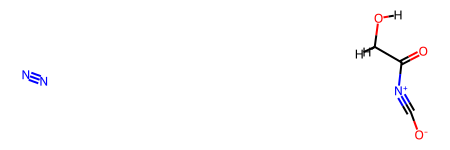

In [27]:
debug_rdkit_molecule

In [28]:
debug_scope_molecule.view(show_indices=True)

AttributeError: 'NoneType' object has no attribute 'view'